# Diabetes Dataset Exploration


#  Import libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
units = {
    "Glucose": "mg/dL",
    "BloodPressure": "mmHg",
    "SkinThickness": "mm",
    "Insulin": "µU/mL",
    "BMI": "kg/m²",
    "Age": "years"
}

# Graph configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load dataset

In [ ]:
df = pd.read_csv('../data/raw/diabetes.csv')

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nFirst rows preview:")
df.head()

Dataset shape: 768 rows x 9 columns

First rows preview:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Descriptive Statistics 


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Messing values & suspecious zeros


In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Suspicious Zeros (physiologically impossible values) ===")
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_columns:
    zeros = (df[col] == 0).sum()
    percentage = (zeros / len(df)) * 100
    print(f"{col}: {zeros} zeros ({percentage:.2f}%)")

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Suspicious Zeros (physiologically impossible values) ===
Glucose: 5 zeros (0.65%)
BloodPressure: 35 zeros (4.56%)
SkinThickness: 227 zeros (29.56%)
Insulin: 374 zeros (48.70%)
BMI: 11 zeros (1.43%)


# Visualization of suspicious zeros

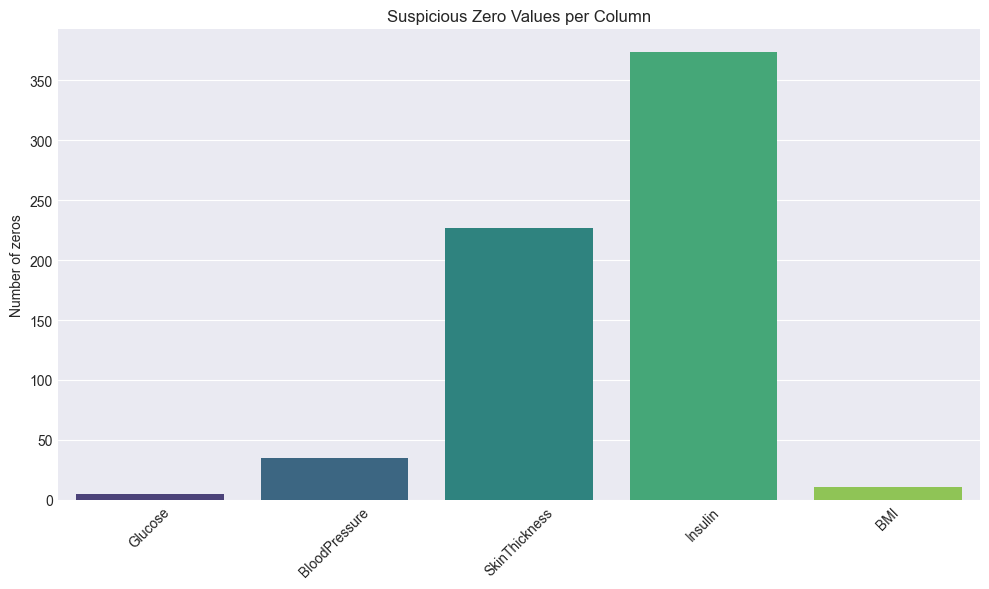

In [5]:
plt.figure(figsize=(10, 6))

zero_counts = [df[col][df[col] == 0].count() for col in zero_columns]

sns.barplot(x=zero_columns, y=zero_counts, palette='viridis')

plt.title('Suspicious Zero Values per Column')
plt.ylabel('Number of zeros')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Target disribution

=== Outcome Distribution ===
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes percentage: 34.90%


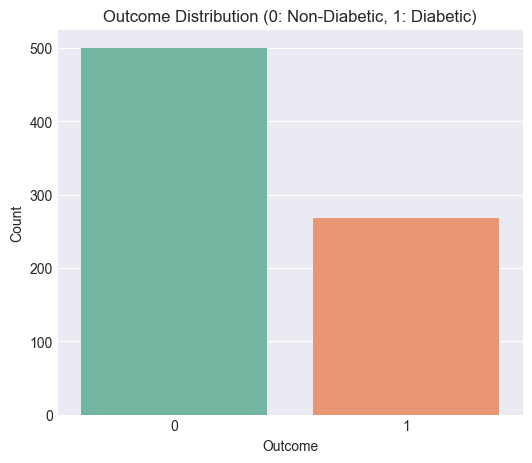

In [6]:
print("=== Outcome Distribution ===")
print(df['Outcome'].value_counts())

print(f"\nDiabetes percentage: {(df['Outcome']==1).mean()*100:.2f}%")

plt.figure(figsize=(6, 5))
sns.countplot(x='Outcome', data=df, palette='Set2')

plt.title('Outcome Distribution (0: Non-Diabetic, 1: Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.show()

# Feature distribution

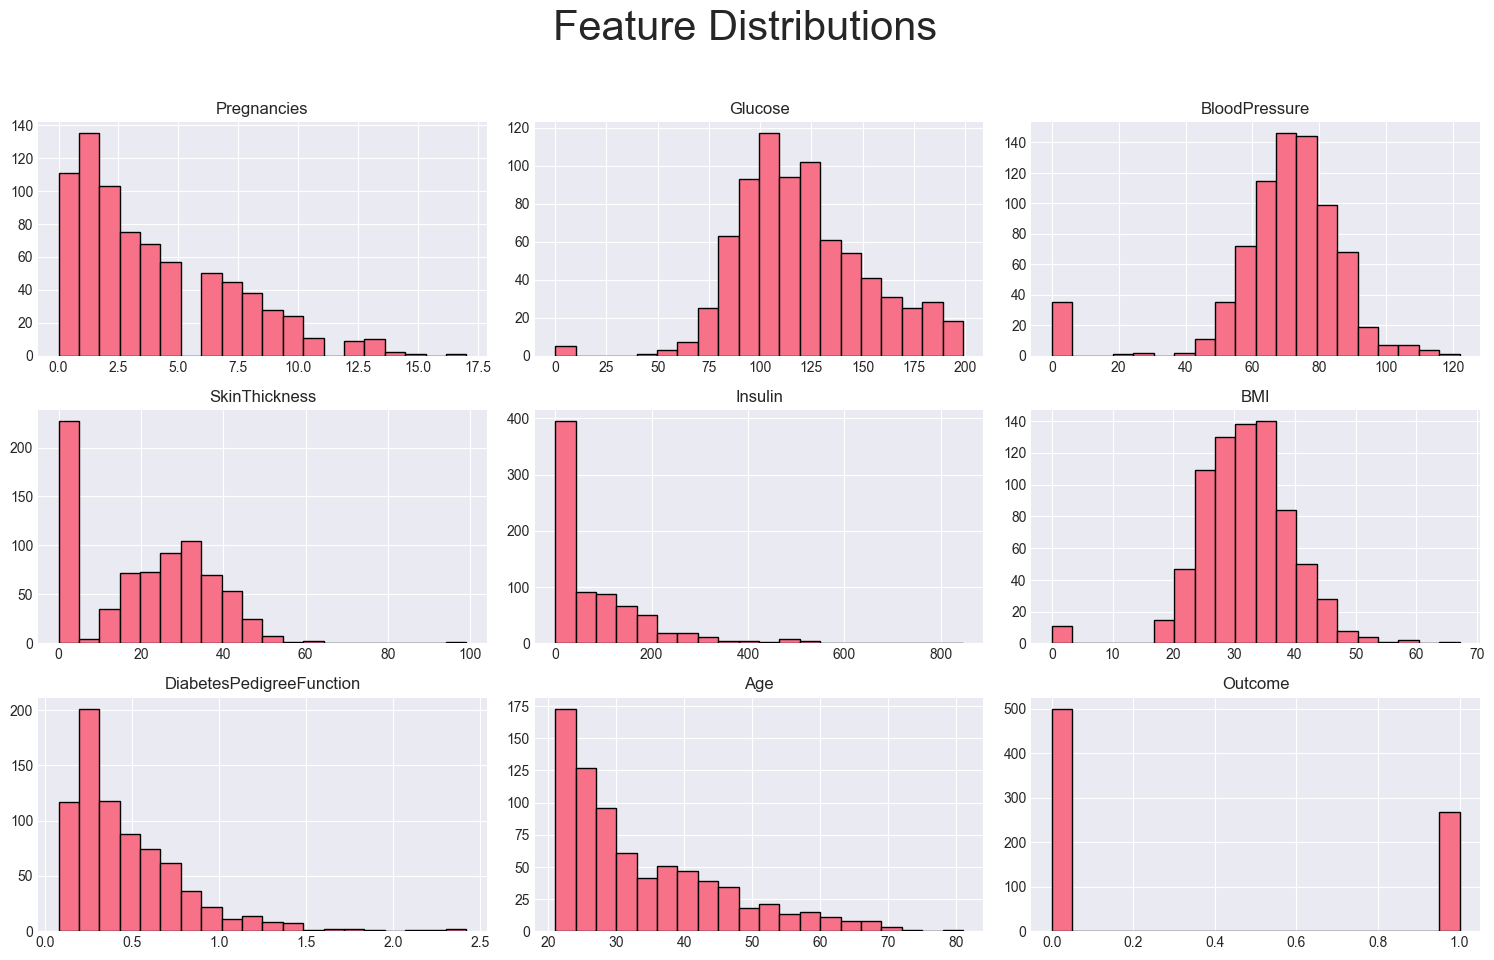

In [7]:
df.hist(figsize=(15, 12), bins=20, edgecolor='black', layout=(4, 3))

plt.suptitle('Feature Distributions', y=1.02, fontsize=30)
plt.tight_layout()
plt.show()

# Boxplots by class

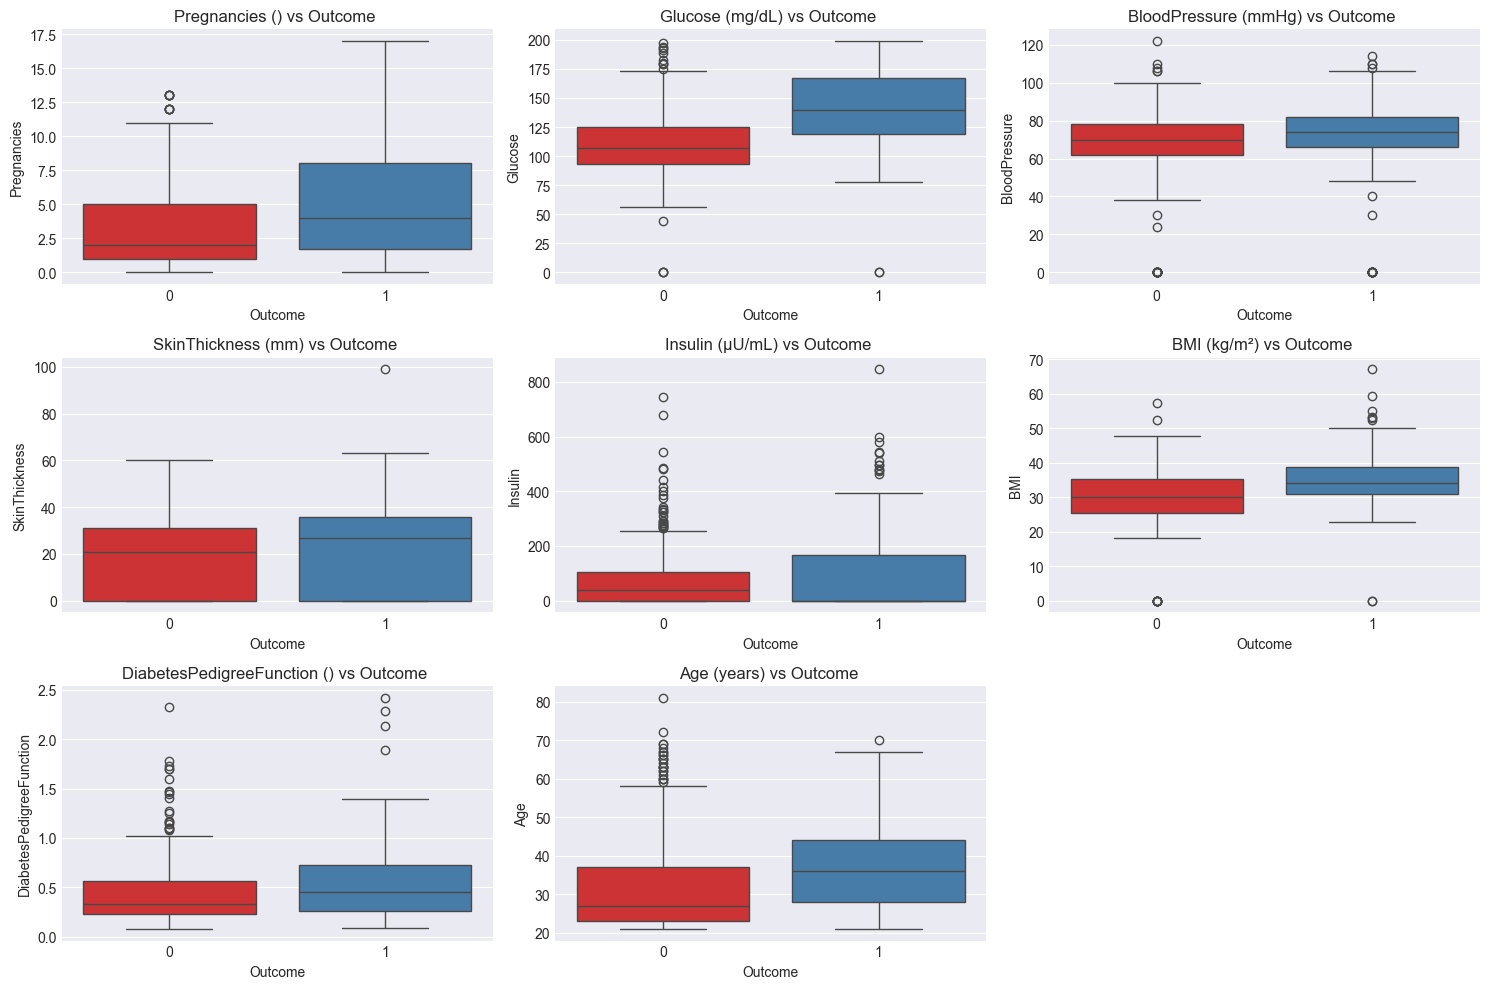

In [8]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Outcome', y=col, data=df, palette='Set1')

    unit = units.get(col, "")  
    plt.title(f'{col} ({unit}) vs Outcome ')

plt.tight_layout()
plt.show()

# Correlation matrix


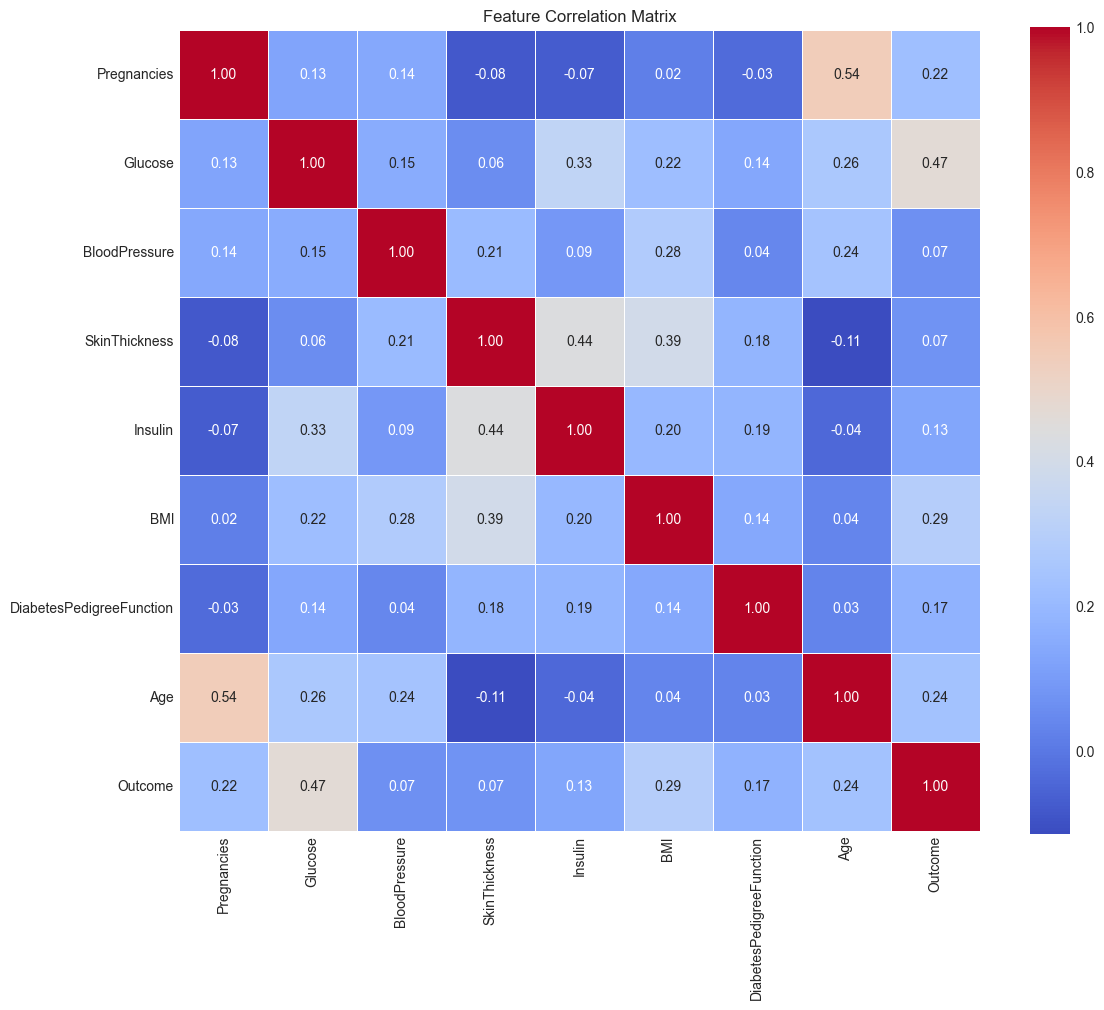

In [ ]:
plt.figure(figsize=(12, 10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
FIGURES_DIR = BASE_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(FIGURES_DIR / f"confusion_matrix_{model.__class__.__name__}.png")
plt.show()

# Correlation with target


In [10]:
print("\n=== Correlation with Outcome ===")
print(df.corr(numeric_only=True)['Outcome'].sort_values(ascending=False))


=== Correlation with Outcome ===
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


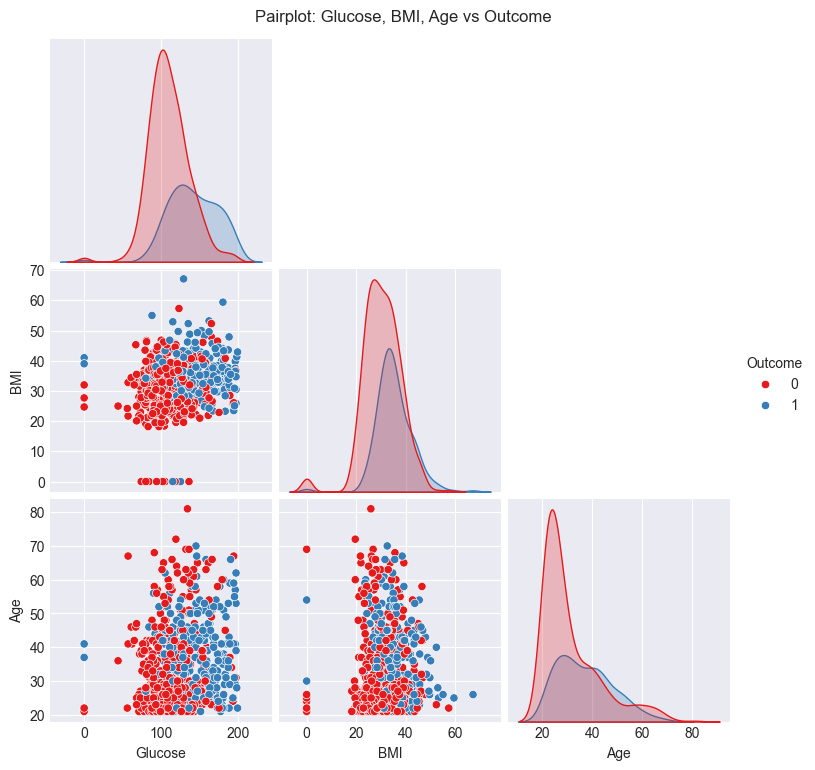

In [11]:
features_to_plot = ['Glucose', 'BMI', 'Age', 'Outcome']

sns.pairplot(
    df[features_to_plot],
    hue='Outcome',
    palette='Set1',
    diag_kind='kde',
    corner=True  # évite duplication
)
plt.suptitle('Pairplot: Glucose, BMI, Age vs Outcome', y=1.02)
plt.show()

In [12]:
#1. Zero values exist in: Glucose, BloodPressure, SkinThickness, Insulin, BMI → need handling
#2. Class imbalance: ~35% diabetic cases → consider SMOTE or class_weight
#3. Most important features: Glucose, BMI, Age
#4. Outliers present → further analysis required